In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime

In [6]:
df = pd.read_excel(r"C:\Users\ageglio\OneDrive - TRC\Midwest Execution - Power Automate Supporting Materials\TRC_Task_Matrix_Master.xlsx", sheet_name="Tasks")

c:\ageglio-1\EDD Data Processor\dataprocessor\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)
c:\ageglio-1\EDD Data Processor\dataprocessor\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


<Axes: title={'center': 'Task Status Distribution'}, ylabel='Status'>

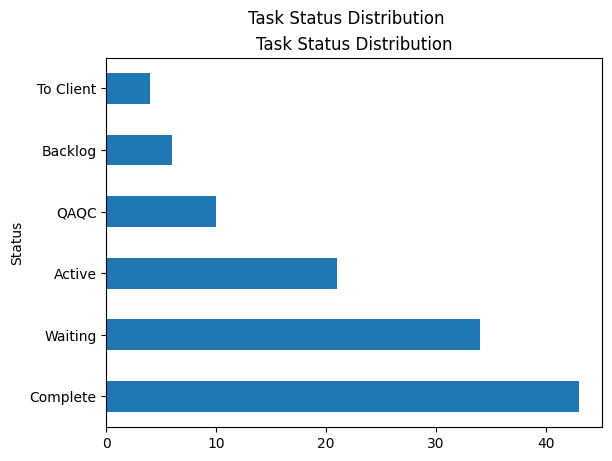

In [14]:
plt.suptitle("Task Status Distribution")
plt.title("Task Status Distribution")
df.Status.value_counts().plot(kind="barh")

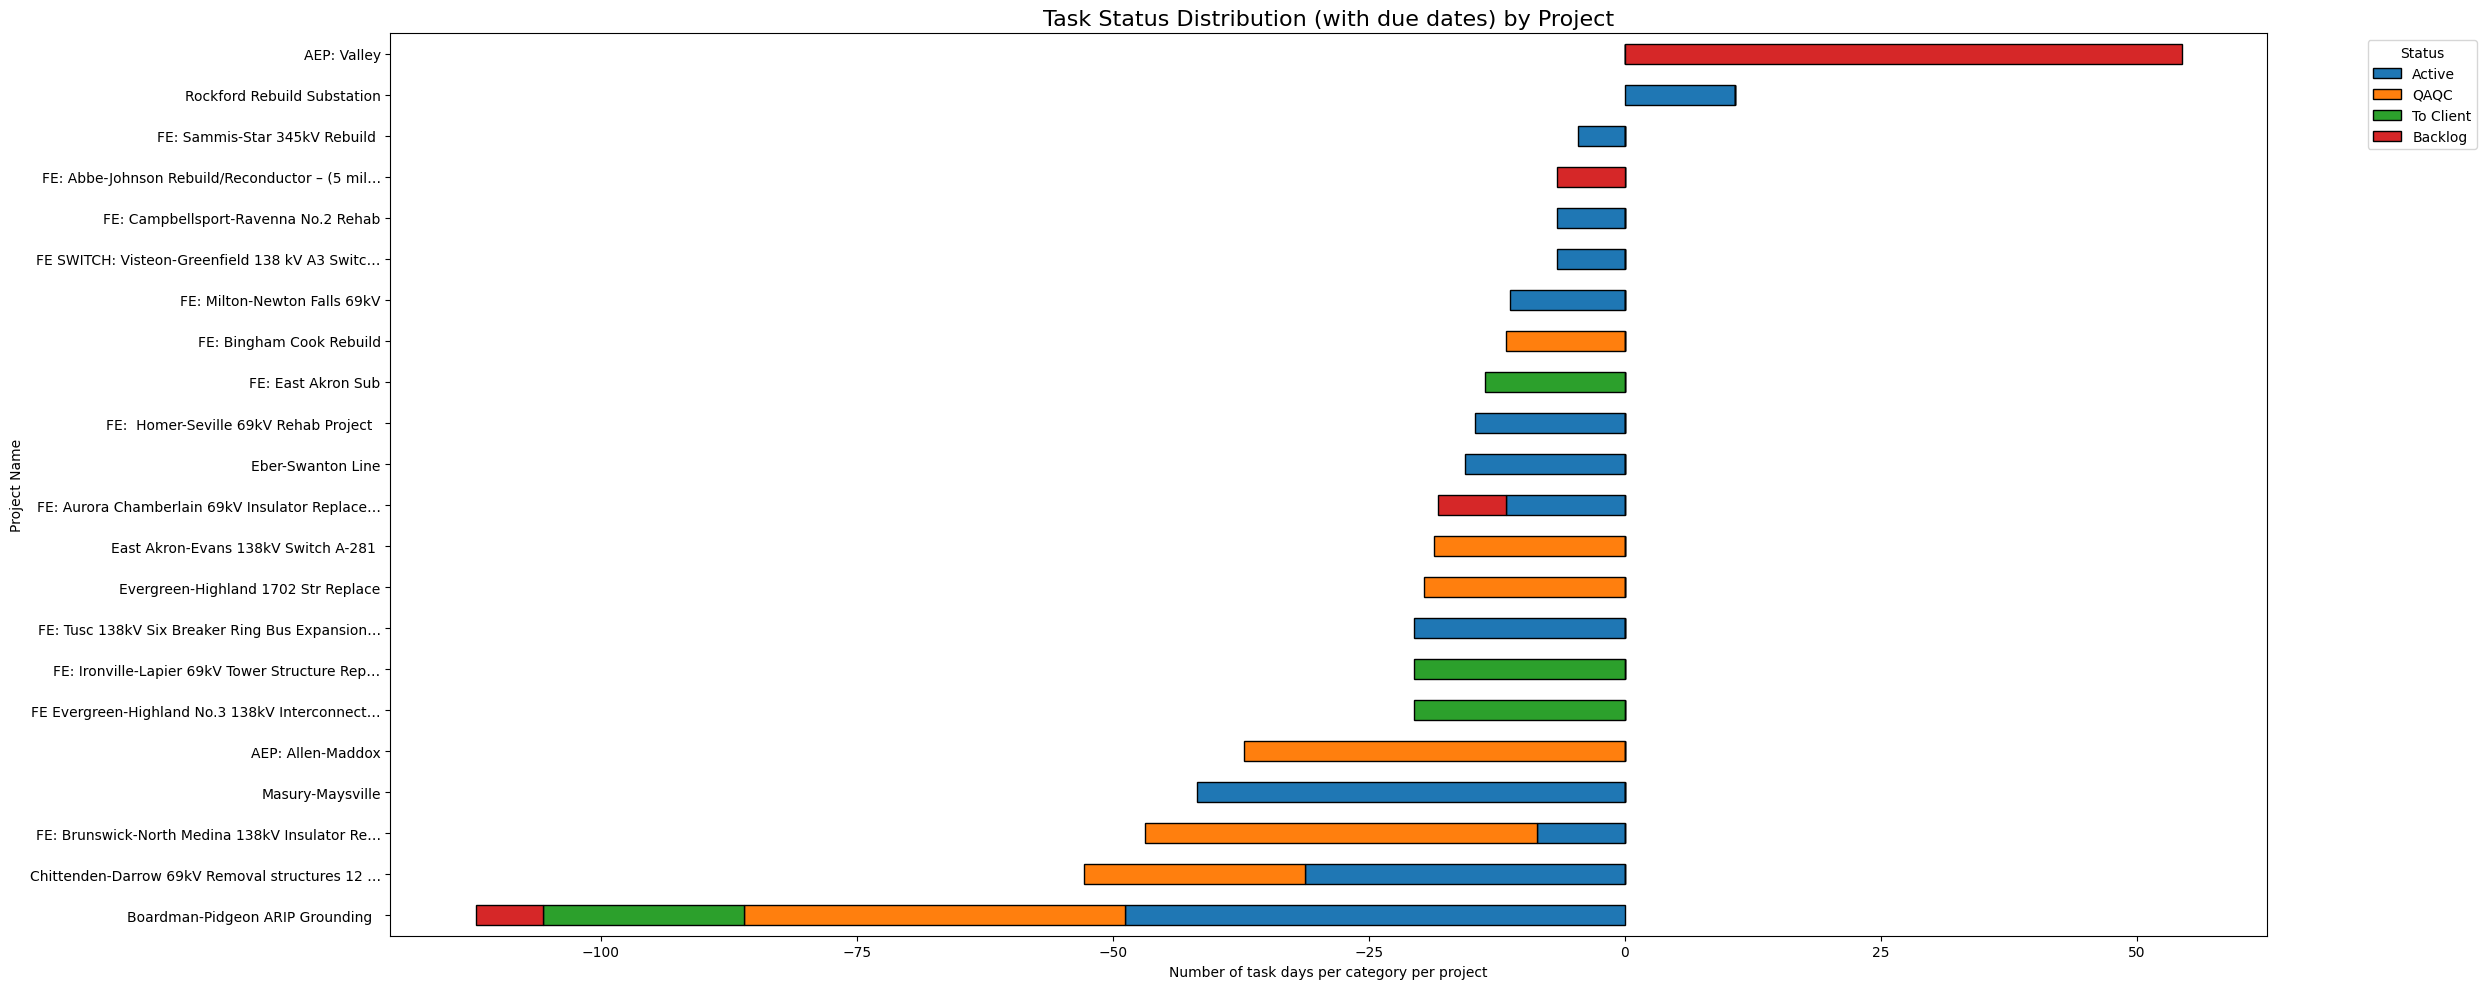

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make DueDate timezone-aware (recommended) and compute time_to_due
df2 = df.copy()
df2["DueDate"] = pd.to_datetime(df2["DueDate"], utc=True)  # use df2 consistently
now = pd.Timestamp.now(tz="UTC")
df2["time_to_due"] = df2["DueDate"] - now   # dtype: timedelta64[ns]

pt2 = df2.pivot_table(
    index="ProjectName",
    columns="Status",
    values="time_to_due",
    aggfunc="sum",
    fill_value=pd.Timedelta(0)  # use zero Timedelta, not int
)

# Convert timedeltas to days (floats)
pt2 = pt2 / pd.Timedelta(days=1)

# Explicit status order (ensure all are present; missing ones become 0)
status_order = ["Active",  "QAQC", "To Client", "Backlog"] #  "Waiting", "Complete",
pt2 = pt2.reindex(columns=status_order, fill_value=0)

# Choose which statuses contribute to "Total_days"
td_cols = ["Active", "QAQC", "To Client", "Backlog"]  # omit "Waiting", 'Complete'
pt2["Total_days"] = pt2[td_cols].sum(axis=1, skipna=True)

# Filter out rows with zero total (abs prevents -0.0 oddities)
pt2 = pt2[pt2["Total_days"].abs() > 0].copy()

# Sort by total ascending
pt2 = pt2.sort_values("Total_days", ascending=True)

# Drop helper column
pt2 = pt2.drop(columns="Total_days")

# Truncate labels
def trunc(name, ellipsis=True, n=20):
    s = str(name)
    return s if len(s) <= n else (s[:n] + "…") if ellipsis else s[:n]

truncated_labels = [trunc(p, n=45) for p in pt2.index]

# --- Plot properly: create fig/ax FIRST, then plot INTO ax ---
custom_cmap = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

fig, ax = plt.subplots(figsize=(25, 10))

# Plot only the columns you want to show (and in the specified order)
cols_to_plot = [c for c in status_order if c in pt2.columns]
pt2[cols_to_plot].plot(
    kind="barh",
    stacked=True,
    color=custom_cmap[:len(cols_to_plot)],
    edgecolor="black",
    ax=ax
)

# Apply labels to the SAME axes
ax.set_yticks(np.arange(len(pt2.index)))
ax.set_yticklabels(truncated_labels)

ax.set_title("Task Status Distribution (with due dates) by Project", fontsize=16)
ax.set_xlabel("Number of task days per category per project")
ax.set_ylabel("Project Name")

ax.legend(title="Status", bbox_to_anchor=(1.05, 1), loc="upper left")
fig.tight_layout()
plt.show()

In [16]:
df[df.ProjectName.str.contains("Boardman-Pidgeon ARIP Grounding")]

,Client,ProjectName,ProjectNumber,TaskType,TaskName,Priority,Status,AssignedToEmail,QAQCReviewerEmail,FinalEmail,DueDate,TemplateName,AdditionalNotes,FolderLink,CreateTask,TaskCreated,Planner Step,StatusLastUpdated,TaskID,UniqueKey
42,FirstEnergy,Boardman-Pidgeon ARIP Grounding,664675.0000.0000 P29,Hauling,Haul route map,NaN,To Client,JLuman@trccompanies.com,AKast@trccompanies.com,PSzpaichler@trccompanies.com,2026-03-19,NaN,QC'd 3.10.26,\\CLEVELAND-VFP\Sys\Projects\FirstEnergy\67743...,Yes,Yes,To Client,NaT,JhyGDlh0okqOIpsseuQI-2QAIh32,44
51,FirstEnergy,Boardman-Pidgeon ARIP Grounding,664675.0000.0000 P29,ROW,NaN,NaN,Active,MBollini@trccompanies.com,NaN,NaN,2026-03-20,NaN,NaN,\\CLEVELAND-VFP\Sys\Projects\FirstEnergy\67743...,Yes,Yes,Active,NaT,Zs4iMr7K_EGgTjghxwi4vGQAGQOe,53
53,FirstEnergy,Boardman-Pidgeon ARIP Grounding,664675.0000.0000 P29,Hauling,RUMA,NaN,Active,MPurvis@trccompanies.com,MBollini@trccompanies.com,MPurvis@trccompanies.com,2026-03-20,NaN,Michelle to work with Ashlyn;,\\CLEVELAND-VFP\Sys\Projects\FirstEnergy\66467...,Yes,Yes,Active,NaT,tJXpb81T9U6Bw8KK6rJSV2QADT0s,55
54,FirstEnergy,Boardman-Pidgeon ARIP Grounding,664675.0000.0000 P29,Floodplain,NaN,NaN,QAQC,JLuman@trccompanies.com,PSzpaichler@trccompanies.com,NaN,2026-03-20,NaN,NaN,\\CLEVELAND-VFP\Sys\Projects\FirstEnergy\67743...,Yes,Yes,QAQC,NaT,rdLEr972_UejQfoxX8EAOWQAL5h2,56
55,FirstEnergy,Boardman-Pidgeon ARIP Grounding,664675.0000.0000 P29,Permit Matrix,NaN,NaN,QAQC,MPurvis@trccompanies.com,MBollini@trccompanies.com,NaN,2026-03-20,NaN,Michelle QC,\\CLEVELAND-VFP\Sys\Projects\FirstEnergy\66467...,Yes,Yes,QAQC,NaT,D-yAy3cUSkWWyEOqbDToZmQAByZN,57
64,FirstEnergy,Boardman-Pidgeon ARIP Grounding,664675.0000.0000 P29,SWPPP,NaN,NaN,Active,AYaasiin@trccompanies.com,MBollini@trccompanies.com,NaN,2026-03-27,NaN,NaN,\\CLEVELAND-VFP\Sys\Projects\FirstEnergy\67743...,Yes,Yes,Active,2026-03-23,MviOHAAkMkWCNqn2f-bmOmQADNGx,66
68,FirstEnergy,Boardman-Pidgeon ARIP Grounding,664675.0000.0000 P29,Permit Binder,NaN,NaN,Backlog,NaN,NaN,NaN,2026-04-01,NaN,NaN,\\CLEVELAND-VFP\Sys\Projects\FirstEnergy\66467...,NaN,NaN,NaN,NaT,NaN,70
89,FirstEnergy,Boardman-Pidgeon ARIP Grounding,664675.0000.0000 P29,Access Map,NaN,NaN,Complete,MPurvis@trccompanies.com,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,91


<Figure size 3500x3500 with 0 Axes>

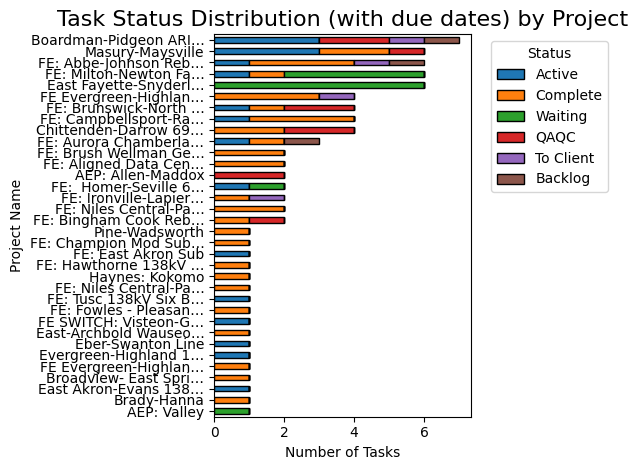

In [30]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Pivot table: rows = project, columns = status
pt = df.pivot_table(
    index="ProjectName",
    columns="Status",
    values="DueDate",
    aggfunc="count",
    fill_value=0
)

# Explicit status order
status_order = ["Active", "Complete", "Waiting", "QAQC", "To Client", "Backlog"]
pt = pt.reindex(columns=status_order, fill_value=0)

# Remove projects with zero total tasks
pt["Total"] = pt.sum(axis=1)
pt = pt[pt["Total"] > 0]

# Sort by total tasks ascending (bottom-up)
pt = pt.sort_values("Total", ascending=True)

# Drop helper column
pt = pt.drop(columns="Total")

# Truncate labels
def trunc20(name, ellipsis=True):
    s = str(name)
    if len(s) <= 20:
        return s
    return (s[:20] + "…") if ellipsis else s[:20]

# Prepare labels
truncated_labels = [trunc20(p) for p in pt.index]

# --- Plot ---
plt.figure(figsize=(35, 35))  # create figure FIRST

custom_cmap = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]  # custom colors for statuses
# Plot the stacked horizontal bar chart
pt.plot(
    kind="barh",
    stacked=True,
    color=custom_cmap,
    edgecolor="black"
)

plt.yticks(ticks=np.arange(len(pt.index)), labels=truncated_labels)

plt.title("Task Status Distribution (with due dates) by Project", fontsize=16)
plt.xlabel("Number of Tasks")
plt.ylabel("Project Name")
plt.legend(title="Status", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


In [31]:
pt

Status,Active,Complete,Waiting,QAQC,To Client,Backlog
ProjectName,,,,,,
AEP: Valley,0,0,1,0,0,0
Brady-Hanna,0,1,0,0,0,0
East Akron-Evans 138kV Switch A-281,1,0,0,0,0,0
Broadview- East Springfield 69kV pole replacement,0,1,0,0,0,0
FE Evergreen-Highland No.3 138kV Interconnect Work order: 17965403 / RPA: OE-25-221116-145616,0,1,0,0,0,0
Evergreen-Highland 1702 Str Replace,1,0,0,0,0,0
Eber-Swanton Line,1,0,0,0,0,0
East-Archbold Wauseon 69kV line,0,1,0,0,0,0
FE SWITCH: Visteon-Greenfield 138 kV A3 Switch Replacement,1,0,0,0,0,0


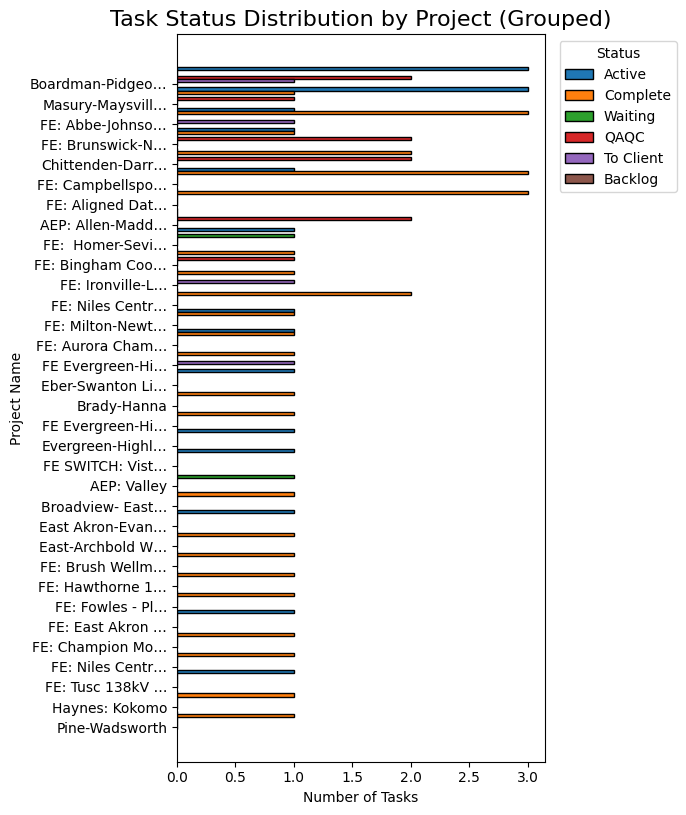

In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ----- Pivot table -----
pt = df.pivot_table(
    index="ProjectName",
    columns="Status",
    values="TaskID",       # or any column to count
    aggfunc="count",
    fill_value=0
)

# Keep a consistent status order
status_order = ["Active", "Complete", "Waiting", "QAQC", "To Client", "Backlog"]
pt = pt.reindex(columns=status_order, fill_value=0)

# ----- Filter out zero-task projects -----
pt["Total"] = pt.sum(axis=1)
pt = pt[pt["Total"] > 0]

# ----- Sort by total tasks (descending, most at top) -----
pt = pt.sort_values("Total", ascending=False)
pt = pt.drop(columns="Total")

# ----- Prepare grouped horizontal bars -----
projects = pt.index.tolist()
statuses = pt.columns.tolist()
values = pt.values

n_projects = len(projects)
n_statuses = len(statuses)

# Vertical positions for project groups
y_positions = np.arange(n_projects)

# spacing: total band height per project; status bars will fit within
band_height = 0.9
bar_height = band_height / n_statuses

# Colors (optional): use Matplotlib defaults if you prefer
# from matplotlib.cm import get_cmap
# cmap = get_cmap("tab20")
# colors = [cmap(i) for i in range(n_statuses)]
colors = None  # uses default cycle

# ----- Make a single figure -----
# Height scales with number of projects for legibility
fig_height = max(6, min(10, 0.25 * n_projects))
plt.figure(figsize=(7, fig_height))

# Draw grouped bars
for j, status in enumerate(statuses):
    offsets = (j - (n_statuses - 1)) * bar_height
    plt.barh(
        y_positions + offsets,
        pt[status].values,
        height=bar_height,   # small gap between bars
        label=status,
        color=None if colors is None else colors[j],
        edgecolor="black"
    )

# Invert Y so highest totals appear at the top
plt.gca().invert_yaxis()

# ----- Truncate labels to first 15 characters -----
def trunc15(name, ellipsis=True):
    s = str(name)
    if len(s) <= 15:
        return s
    return (s[:15] + "…") if ellipsis else s[:15]

truncated_labels = [trunc15(p) for p in projects]
plt.yticks(y_positions, truncated_labels)

plt.xlabel("Number of Tasks")
plt.ylabel("Project Name")
plt.title("Task Status Distribution by Project (Grouped)", fontsize=16)

plt.legend(title="Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

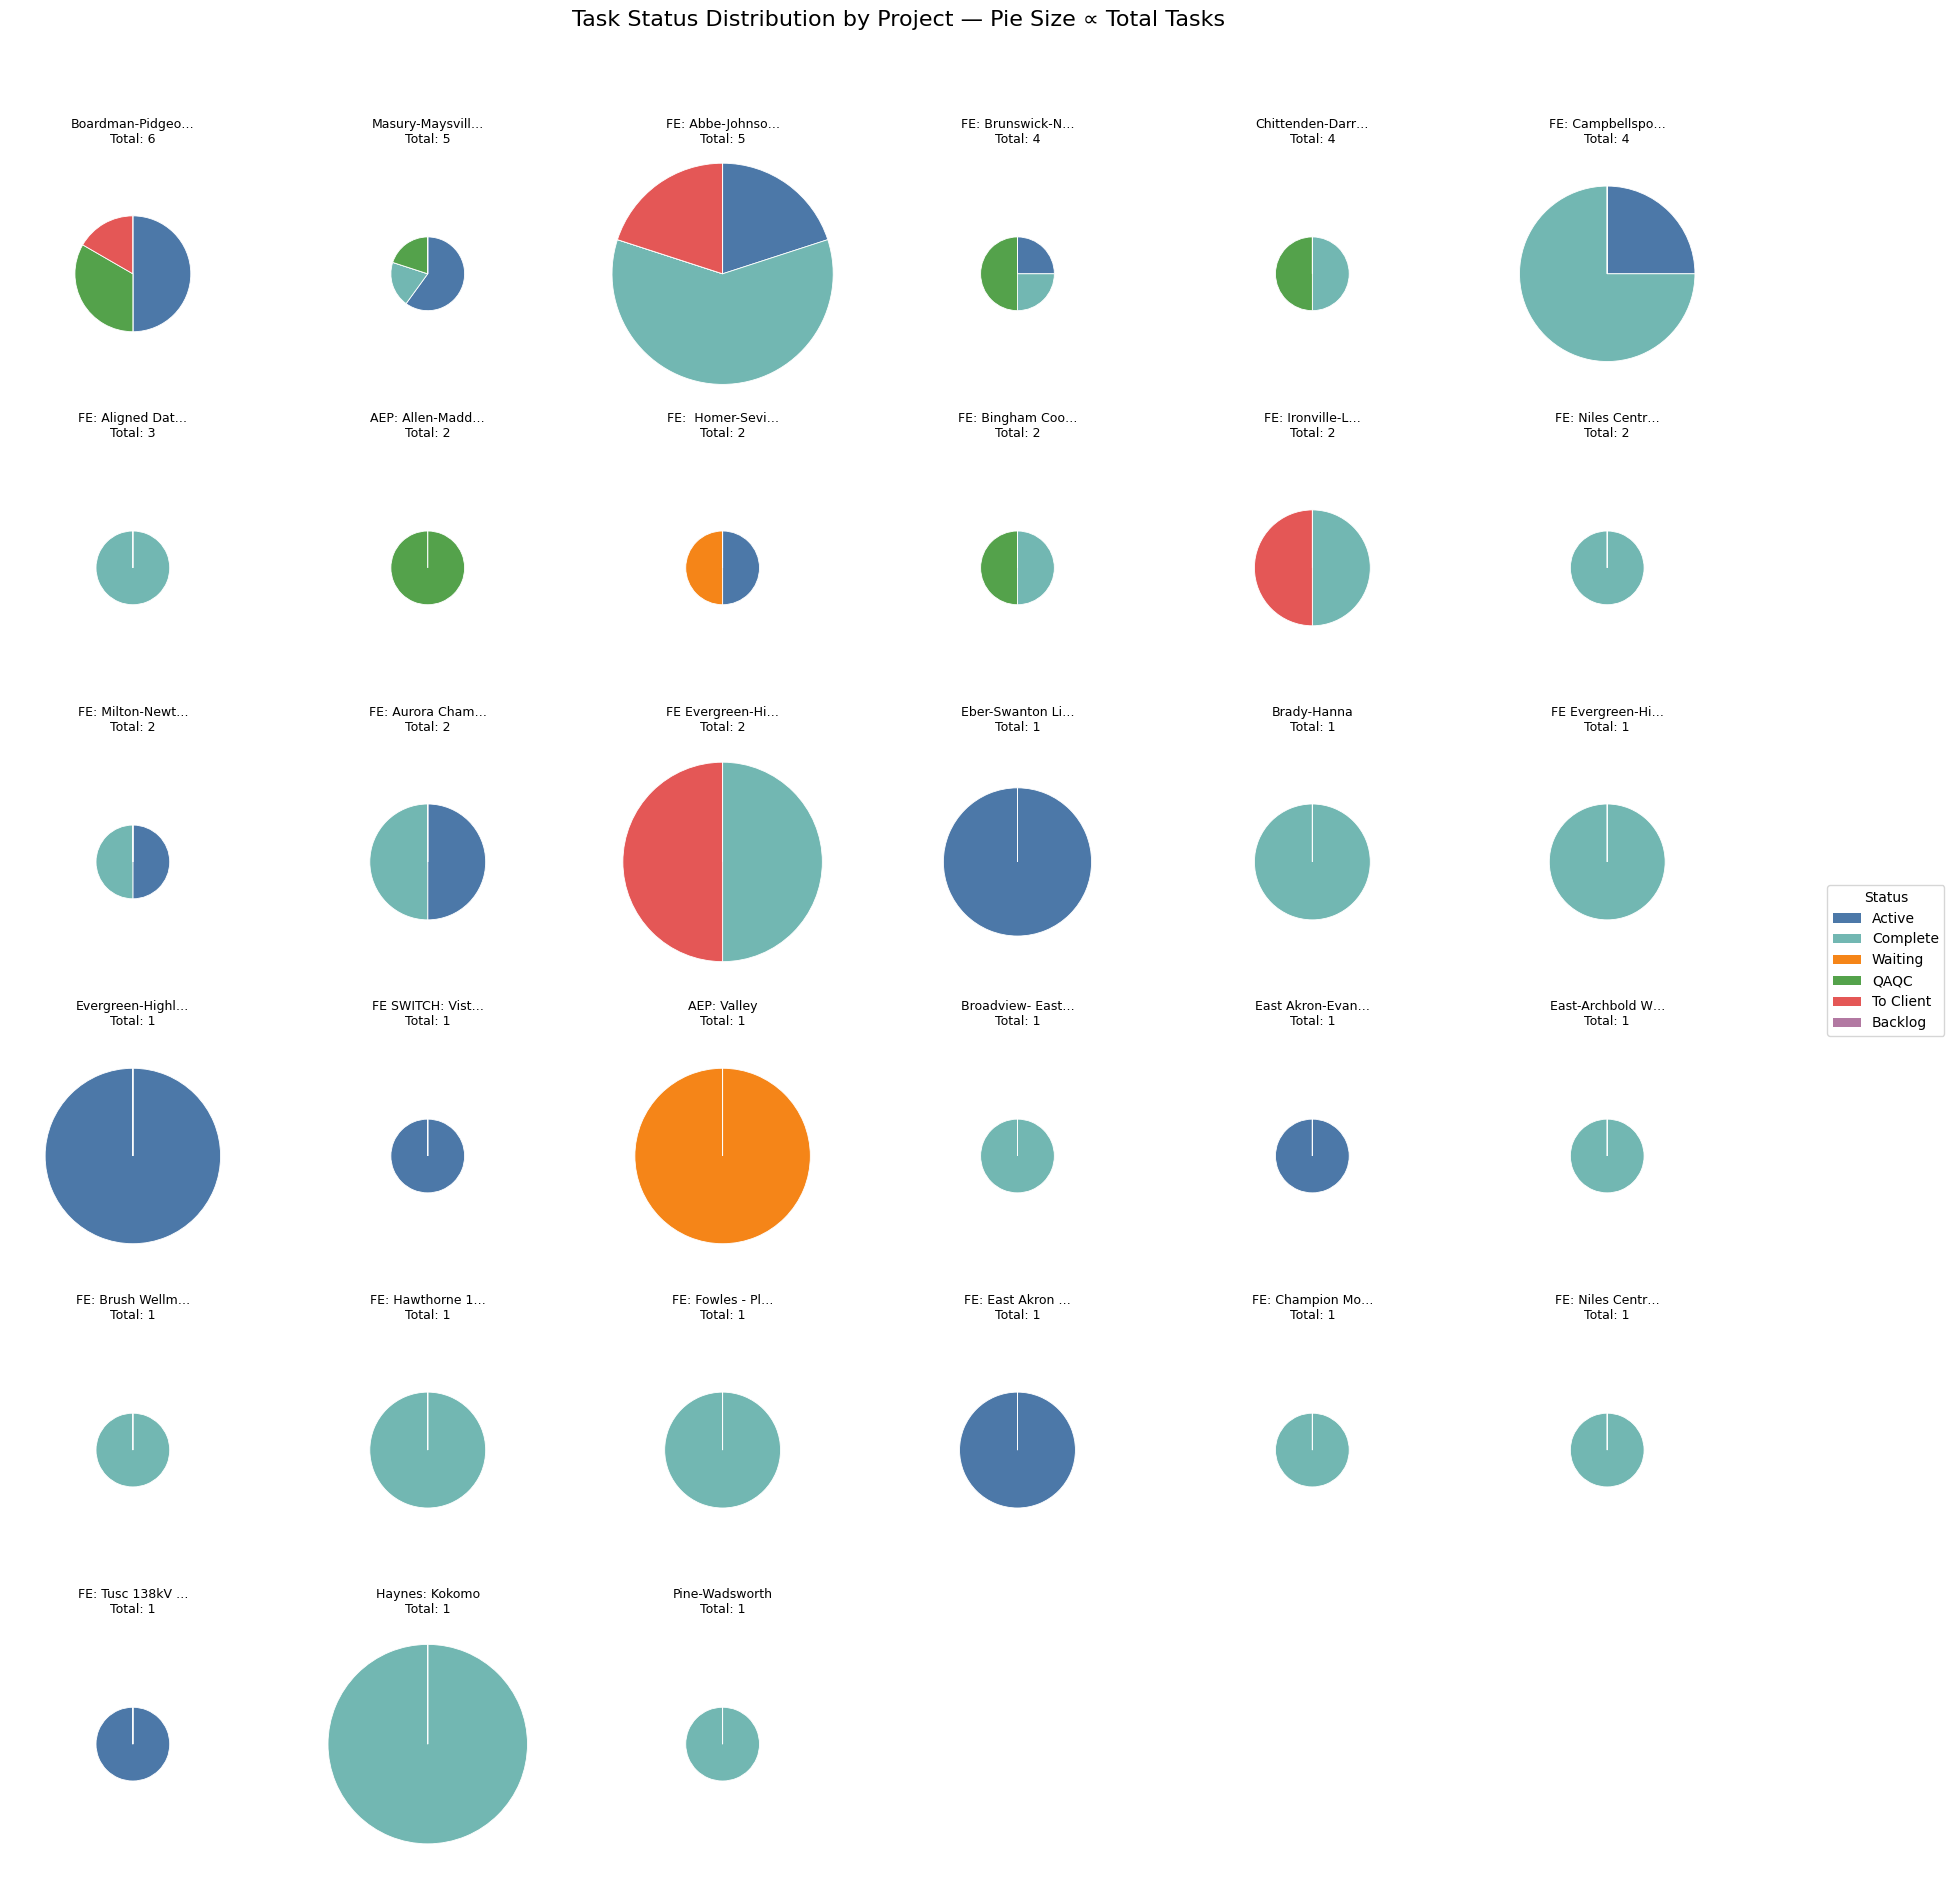

In [33]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.patches import Patch

# ----- Build a project × status table of counts -----
pt = df.pivot_table(
    index="ProjectName",
    columns="Status",
    values="TaskID",       # or any column to count
    aggfunc="count",
    fill_value=0
)

# Keep a consistent status order
status_order = ["Active", "Complete", "Waiting", "QAQC", "To Client", "Backlog"]
pt = pt.reindex(columns=status_order, fill_value=0)

# ----- Filter out zero‑task projects and sort by total -----
totals = pt.sum(axis=1)
pt = pt.loc[totals > 0]
totals = totals.loc[pt.index]
pt = pt.loc[totals.sort_values(ascending=False).index]

# ----- Pie size scaling: area ∝ total tasks (radius ∝ sqrt(total)) -----
sqrt_tot = np.sqrt(totals.values.astype(float))
r_min, r_max = 0.30, 0.90  # relative radii bounds within each subplot
if sqrt_tot.max() > sqrt_tot.min():
    radii = r_min + (sqrt_tot - sqrt_tot.min()) / (sqrt_tot.max() - sqrt_tot.min()) * (r_max - r_min)
else:
    radii = np.full_like(sqrt_tot, (r_min + r_max) / 2.0)

# ----- Grid layout (single figure) -----
projects = pt.index.tolist()
N = len(projects)
# Choose a near‑square grid but keep it readable
cols = min(6, max(3, int(np.ceil(np.sqrt(N)))))
rows = int(np.ceil(N / cols))

fig_w = cols * 3.2
fig_h = rows * 3.2
fig, axes = plt.subplots(rows, cols, figsize=(fig_w, fig_h), subplot_kw=dict(aspect='equal'))
axes = np.atleast_1d(axes).reshape(rows, cols)

# Optional: pick colors per status (consistent across pies)
# You can swap this palette; these are pleasant, distinct colors
status_colors = {
    "Active":    "#4C78A8",
    "Complete":  "#72B7B2",
    "Waiting":   "#F58518",
    "QAQC":      "#54A24B",
    "To Client": "#E45756",
    "Backlog":   "#B279A2",
}
color_list = [status_colors[s] for s in status_order]

# Helper to truncate labels
def trunc15(s, ellipsis=True):
    s = str(s)
    return s if len(s) <= 15 else (s[:15] + "…") if ellipsis else s[:15]

# ----- Draw each pie -----
k = 0
for r in range(rows):
    for c in range(cols):
        ax = axes[r, c]
        if k >= N:
            ax.axis('off')
            continue

        proj = projects[k]
        vals = pt.loc[proj].values.astype(float)
        rad  = radii[k]
        total = int(totals.loc[proj])

        # Draw pie for this project
        wedges, _ = ax.pie(
            vals,
            colors=color_list,
            radius=rad,
            startangle=90,
            counterclock=False,
            wedgeprops=dict(edgecolor='white', linewidth=0.6)
        )

        # Title: truncated name + total
        ax.set_title(f"{trunc15(proj)}\nTotal: {total}", fontsize=9, pad=6)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)

        k += 1

# ----- Shared legend (one per figure) -----
handles = [Patch(facecolor=status_colors[s], label=s) for s in status_order]
fig.legend(handles=handles, title="Status", loc="center left", bbox_to_anchor=(0.98, 0.5))

fig.suptitle("Task Status Distribution by Project — Pie Size ∝ Total Tasks", fontsize=16, y=0.995)
plt.tight_layout(rect=[0.02, 0.02, 0.95, 0.965])
plt.show()